# Midterm Project - Team 9

**Members:** Alan Ray · Zach Shotwell · Miguel Moreno Coin  
Team project - CS 4440 Artificial Intelligence, Appalachian State University  
**GitHub:** https://github.com/rayar93/ml-classification-regression-sklearn

This notebook covers two end-to-end supervised learning tasks on real-world datasets.

| Task | Dataset | Target | Models |
|------|---------|--------|--------|
| Classification | CEE Student Performance | `performance` (4 classes) | kNN · Logistic Regression · Gaussian NB |
| Regression | Auction Verification | `verification.time` (seconds) | kNN · SVR · Random Forest |

## Setup

In [82]:
import numpy as np
SEED = 42
np.random.seed(SEED)

from scipy.io import arff
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2, f_regression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, 
    classification_report, mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Entrance Exam Classification Project

**Dataset:** Student Entrance Exam (CEE) dataset in ARFF format. Each instance
represents a student described by demographic and academic features.  
**Task:** Predict academic performance category — *Average*, *Good*, *Very Good*,
or *Excellent* — a four-class classification problem (25% random-chance baseline).  
**Approach:** After dropping a feature with two singleton classes and encoding categorical inputs,
we compare three classifiers with 10-fold cross-validation, then tune the
best-performing model with `GridSearchCV`.

## Data Wrangling

### Load ARFF into a DataFrame

In [83]:
# Load the ARFF file and convert it to a DataFrame (of bytes)
data, meta = arff.loadarff("../data/raw/CEE_DATA.arff")
df = pd.DataFrame(data)

# Decode byte strings to regular strings for all columns
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is of type object (bytes)
        df[column] = df[column].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

# Remove whitespace and uppercasing from column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Rename a few columns for clarity
df.rename(columns={
    'class_ten_education': 'class_10_education',
    'twelve_education': 'class_12_education',
    'class__x_percentage': 'class_10_percentage',
    'class_xii_percentage': 'class_12_percentage'
}, inplace=True)

### Examining the data structure

In [84]:
print('First five rows of DataFrame: \n', df.head(), '\n')
print('Shape of DataFrame: ', df.shape, '\n')

First five rows of DataFrame: 
   performance gender    caste coaching time class_10_education  \
0   Excellent   male  General       NO  ONE               SEBA   
1   Excellent   male      OBC       WA  TWO               SEBA   
2   Excellent   male      OBC       OA  TWO             OTHERS   
3   Excellent   male  General       WA  ONE               SEBA   
4   Excellent   male  General       OA  TWO               SEBA   

  class_12_education   medium class_10_percentage class_12_percentage  \
0              AHSEC  ENGLISH           Excellent           Excellent   
1              AHSEC   OTHERS           Excellent           Excellent   
2               CBSE  ENGLISH           Excellent           Excellent   
3              AHSEC   OTHERS           Excellent           Excellent   
4               CBSE  ENGLISH           Excellent           Excellent   

  father_occupation mother_occupation  
0            DOCTOR            OTHERS  
1    SCHOOL_TEACHER        HOUSE_WIFE  
2          B

#### Check for missing values

In [85]:
print('There are no non-null values: ')
print(df.info(), '\n')

There are no non-null values: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 666 entries, 0 to 665
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   performance          666 non-null    object
 1   gender               666 non-null    object
 2   caste                666 non-null    object
 3   coaching             666 non-null    object
 4   time                 666 non-null    object
 5   class_10_education   666 non-null    object
 6   class_12_education   666 non-null    object
 7   medium               666 non-null    object
 8   class_10_percentage  666 non-null    object
 9   class_12_percentage  666 non-null    object
 10  father_occupation    666 non-null    object
 11  mother_occupation    666 non-null    object
dtypes: object(12)
memory usage: 62.6+ KB
None 



#### Check for implicit missing values

In [86]:
print('There are no implicit missing values: \n', df.apply(lambda c: c.str.upper().isin(["NA", "N/A", "?", ""]).sum()), '\n')

There are no implicit missing values: 
 performance            0
gender                 0
caste                  0
coaching               0
time                   0
class_10_education     0
class_12_education     0
medium                 0
class_10_percentage    0
class_12_percentage    0
father_occupation      0
mother_occupation      0
dtype: int64 



#### Drop duplicate values

In [87]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicate rows ({len(df)} remaining)")

Removed 44 duplicate rows (622 remaining)


#### Check feature counts

Target `performance` has 4 classes; Excellent is the smallest of them.
Several predictors (`coaching`, `medium`) are imbalanced.
All input features are categorical.

In [88]:
print(df["performance"].value_counts())
print(df["performance"].value_counts(normalize=True))
print(df["gender"].value_counts())
print(df["caste"].value_counts())
print(df["coaching"].value_counts())
print(df["time"].value_counts())
print(df["class_10_education"].value_counts())
print(df["class_12_education"].value_counts())
print(df["class_10_percentage"].value_counts())
print(df["class_12_percentage"].value_counts())
print(df["medium"].value_counts())
print(df["father_occupation"].value_counts())
print(df["mother_occupation"].value_counts())

performance
Good         194
Vg           178
Average      152
Excellent     98
Name: count, dtype: int64
performance
Good         0.311897
Vg           0.286174
Average      0.244373
Excellent    0.157556
Name: proportion, dtype: float64
gender
male      334
female    288
Name: count, dtype: int64
caste
General    299
OBC        154
ST         103
SC          66
Name: count, dtype: int64
coaching
WA    413
NO    144
OA     65
Name: count, dtype: int64
time
TWO      339
ONE      185
THREE     85
FOUR      11
FIVE       1
SEVEN      1
Name: count, dtype: int64
class_10_education
SEBA      375
CBSE      226
OTHERS     21
Name: count, dtype: int64
class_12_education
AHSEC     348
CBSE      266
OTHERS      8
Name: count, dtype: int64
class_10_percentage
Excellent    469
Vg           100
Good          40
Average       13
Name: count, dtype: int64
class_12_percentage
Excellent    362
Vg           174
Good          74
Average       12
Name: count, dtype: int64
medium
ENGLISH     495
OTHERS   

In [124]:
# Frequency table — target distribution
print(df["performance"].value_counts().to_frame("count").assign(
    proportion=df["performance"].value_counts(normalize=True).round(3)
))

             count  proportion
performance                   
Good           194       0.312
Vg             178       0.286
Average        152       0.244
Excellent       98       0.158


### Create the Target and Set Aside a Test Set

In [89]:
X = df.drop(columns=["performance"])
y = df["performance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

### Visualize Distribution

The `time` feature has two singleton classes that may need to be excluded.

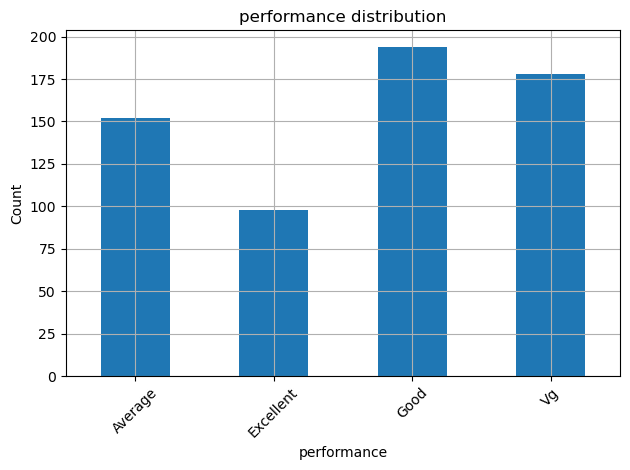

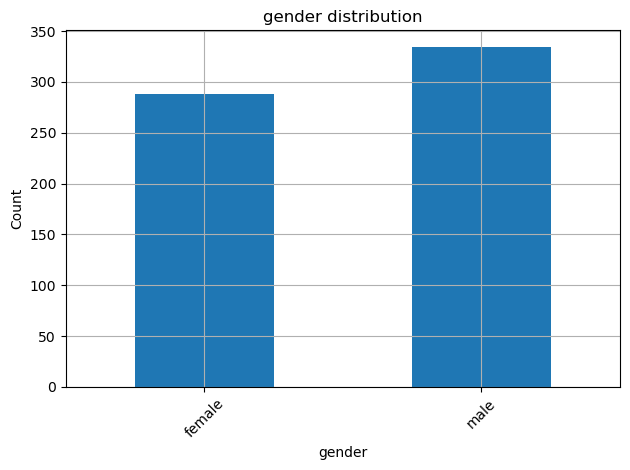

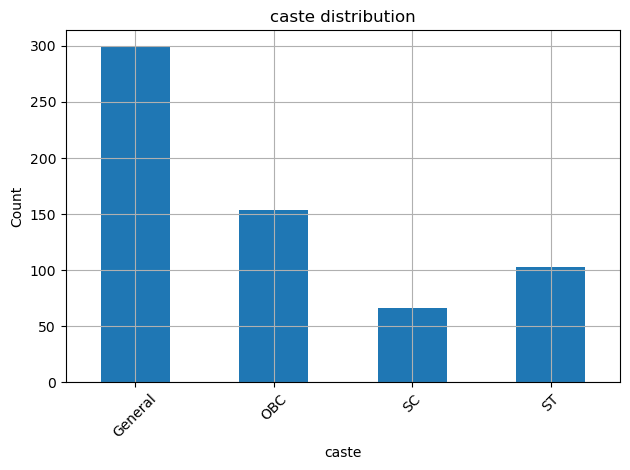

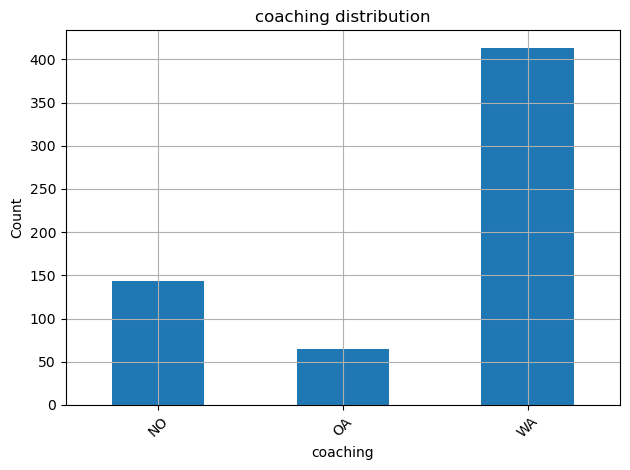

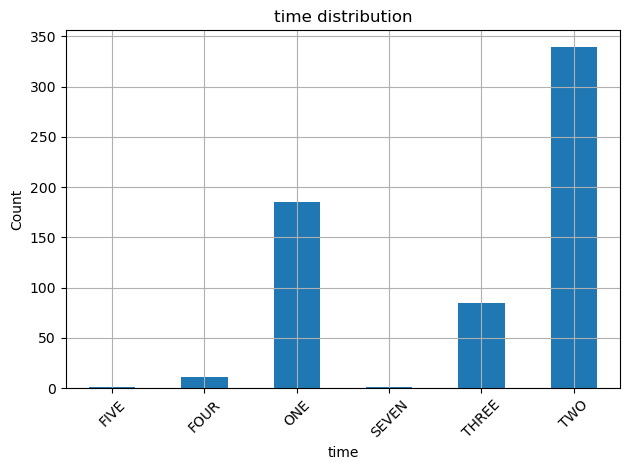

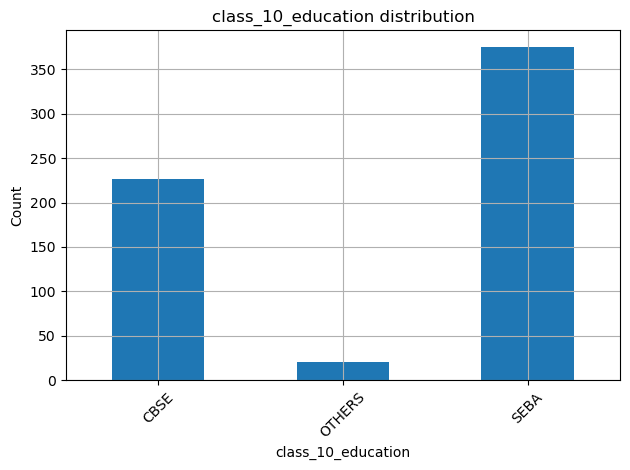

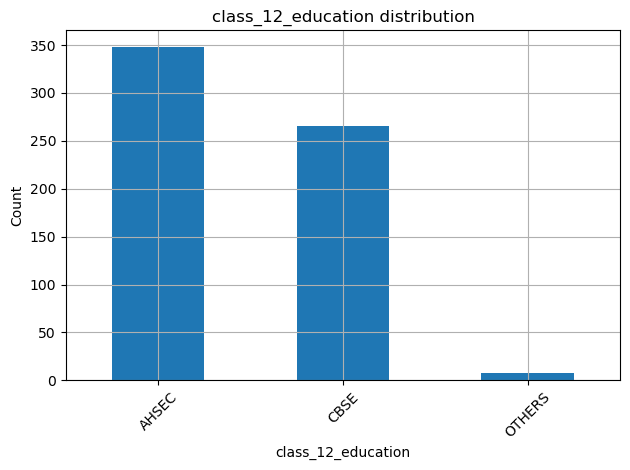

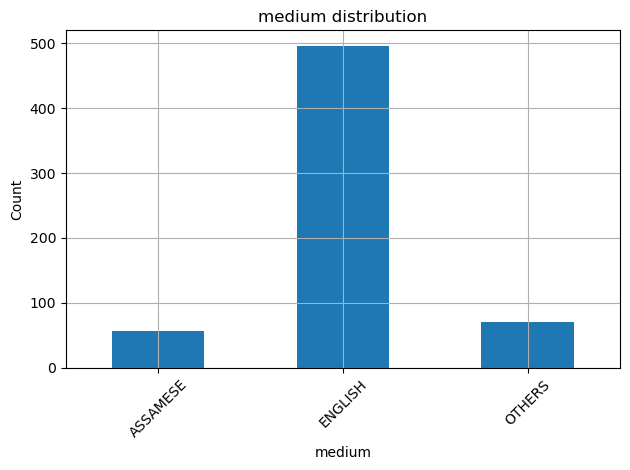

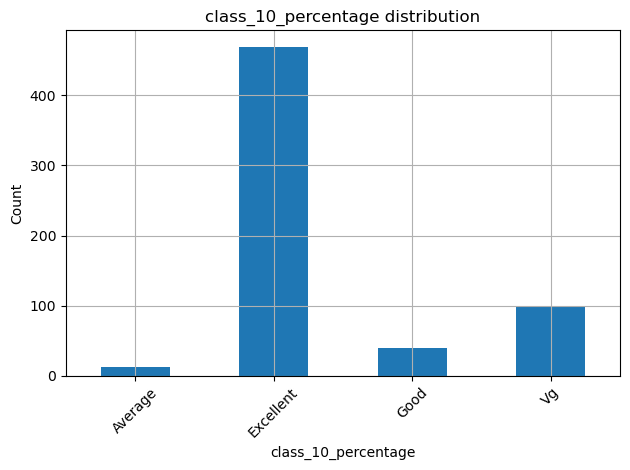

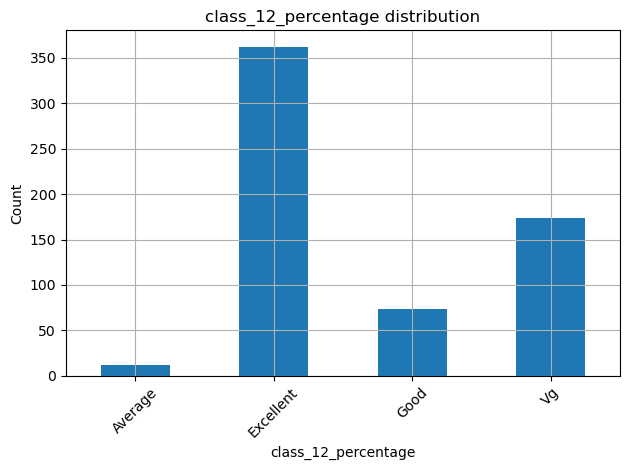

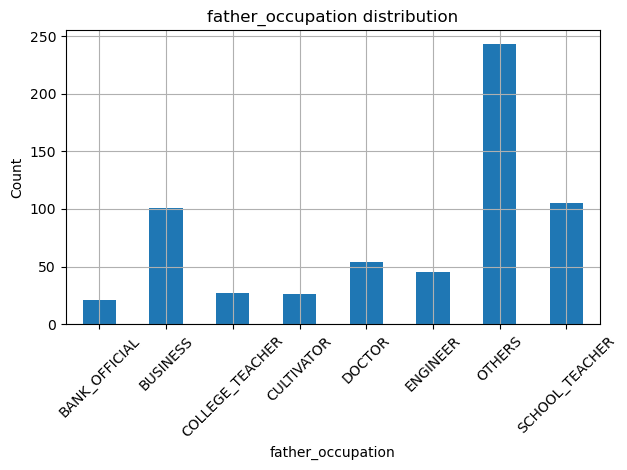

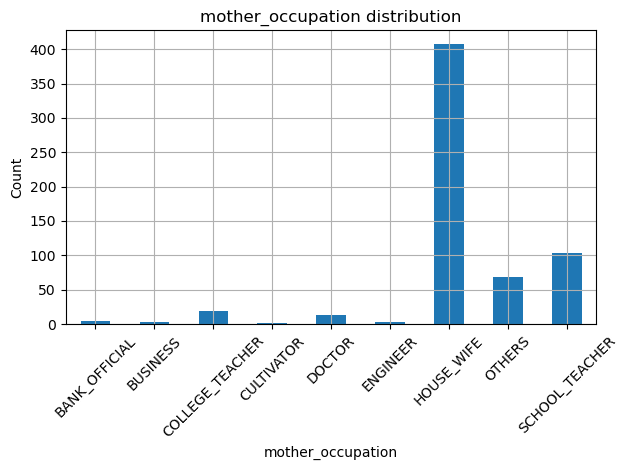

In [90]:
for col in df.columns:
    counts = df[col].value_counts()
    counts = counts.sort_index()

    counts.plot.bar(rot=45, grid=True)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

### Look for Relationships and Correlations

Here we find the conditional distributions for every value of every input feature.
The conditional distribution is the fraction of a group that falls into a certain outcome class.
For example, in row 1: 24.7% of females had Average performance. 11.9% were in Excellent, 32.2% in Good, and 31.2% Vg (Very good). Some features (`caste`) are associated with big shifts in performance.

In [91]:
target = "performance"
features = [c for c in df.columns if c != target]

for c in features:
    print("\n==", c, "==")
    print(pd.crosstab(df[c], df[target], normalize="index"))


== gender ==
performance   Average  Excellent      Good        Vg
gender                                              
female       0.260417   0.121528  0.319444  0.298611
male         0.230539   0.188623  0.305389  0.275449

== caste ==
performance   Average  Excellent      Good        Vg
caste                                               
General      0.000000   0.267559  0.341137  0.391304
OBC          0.162338   0.097403  0.435065  0.305195
SC           0.469697   0.045455  0.303030  0.181818
ST           0.932039   0.000000  0.048544  0.019417

== coaching ==
performance   Average  Excellent      Good        Vg
coaching                                            
NO           0.277778   0.138889  0.326389  0.256944
OA           0.138462   0.353846  0.292308  0.215385
WA           0.249395   0.133172  0.309927  0.307506

== time ==
performance   Average  Excellent      Good        Vg
time                                                
FIVE         0.000000   0.000000  1.000000  

### Clean Data

The feature `time` has two classes with a single record each, producing misleading results in the conditional distributions. It's also unclear what the feature actually records, and the dataset's publisher provides no description of the feature. For all these reasons, we choose to drop this feature.

In [92]:
X_train = X_train.drop(columns=['time'])
X_test = X_test.drop(columns=['time'])
df = df.drop(columns=['time'])

df.to_csv("../data/processed/CEE_DATA.csv", index=False)

## Feature Transformation

### Encode the Target Variable

In [93]:
target_mapping = {'Average': 0, 'Good': 1, 'Vg': 2, 'Excellent': 3}
y_train_mapped = y_train.map(target_mapping)

### Define the Preprocessing Pipeline

In [94]:
percentage_order = ['Average', 'Good', 'Vg', 'Excellent']

preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=[percentage_order, percentage_order]),
         ['class_10_percentage', 'class_12_percentage']),
        
        ('nom', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         ['gender', 'caste', 'coaching', 'medium', 'father_occupation', 'mother_occupation', 'class_10_education', 'class_12_education'])
    ])

## Baseline Models

### Build Baseline Model Pipelines

In [95]:
knn_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

log_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED))
])

gnb_pipe = Pipeline([
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=chi2, k=15)),
    ('model', GaussianNB())
])

### Initial Evaluation via Cross-Validation

Logistic Regression performed best at 52% accuracy (versus 25% for random chance).

In [96]:
models = [('kNN', knn_pipe), ('Logistic Regression', log_pipe), ('Gaussian NB', gnb_pipe)]

for name, pipeline in models:
    results = cross_validate(
        pipeline, X_train, y_train_mapped, 
        cv=10, 
        scoring=['accuracy', 'f1_macro'],
        return_train_score=True)

    train_acc = results['train_accuracy'].mean()
    val_acc = results['test_accuracy'].mean()
    std_acc = results['test_accuracy'].std()
    val_f1 = results['test_f1_macro'].mean()

    print(f"{name}: Train Accuracy: {train_acc:.4f} | Validation Accuracy: {val_acc:.4f} "
          f"(+/- {std_acc:.4f}) | Macro F1: {val_f1:.4f}")
    if train_acc > val_acc * 1.20:
        print(f" Warning: {name} may be overfitting the training data.")

kNN: Train Accuracy: 0.5518 | Validation Accuracy: 0.4284 (+/- 0.0416) | Macro F1: 0.3906
Logistic Regression: Train Accuracy: 0.5638 | Validation Accuracy: 0.5171 (+/- 0.0717) | Macro F1: 0.4896
Gaussian NB: Train Accuracy: 0.4469 | Validation Accuracy: 0.4305 (+/- 0.0634) | Macro F1: 0.3519


## Hyperparameter Tuning

We tune all three models with `GridSearchCV` and 10-fold cross-validation.
Logistic Regression searches over regularization strength and feature count (52 candidates).
kNN searches over k, distance weighting, and metric (100 candidates).
GaussianNB searches over the variance smoothing parameter (12 candidates).
The best classifier — Logistic Regression at 52.1% CV accuracy — is carried forward to final evaluation.

In [97]:
knn_param_grid = {
    'select__k': [9, 13, 15, 17, 21],
    'model__n_neighbors': [3, 5, 7, 9, 11],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(knn_pipe, knn_param_grid, cv=10, scoring='accuracy', verbose=1)
knn_grid.fit(X_train, y_train_mapped)
print(f"KNN best params: {knn_grid.best_params_}")
print(f"KNN best CV accuracy: {knn_grid.best_score_:.4f}")

Fitting 10 folds for each of 100 candidates, totalling 1000 fits
KNN best params: {'model__metric': 'euclidean', 'model__n_neighbors': 11, 'model__weights': 'distance', 'select__k': 9}
KNN best CV accuracy: 0.4850


In [98]:
param_grid = [
    {
        'select__k': [5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29],
        'model__C': [0.01, 0.1, 1, 10]
    }
]

grid_search = GridSearchCV(log_pipe, param_grid, cv=10, scoring='accuracy', verbose=1)

grid_search.fit(X_train, y_train_mapped)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 10 folds for each of 52 candidates, totalling 520 fits
Best parameters: {'model__C': 0.1, 'select__k': 15}
Best CV accuracy: 0.5211


In [99]:
gnb_param_grid = {
    'model__var_smoothing': np.logspace(-12, -1, 12)
}
gnb_grid = GridSearchCV(gnb_pipe, gnb_param_grid, cv=10, scoring='accuracy', verbose=1)
gnb_grid.fit(X_train, y_train_mapped)
print(f"GNB best params: {gnb_grid.best_params_}")
print(f"GNB best CV accuracy: {gnb_grid.best_score_:.4f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits
GNB best params: {'model__var_smoothing': np.float64(0.1)}
GNB best CV accuracy: 0.5091


## Final Evaluation

### Results

In [100]:
y_test_mapped = y_test.map(target_mapping)

final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test_mapped, final_predictions)
print(f"Final test set accuracy: {final_accuracy:.4f}")

Final test set accuracy: 0.5440


### Confusion Matrix

The confusion matrix shows that while our model does misclassify ~46% of instances, it usually misclassifies them into adjacent categories - for example, it didn't misclassify any Excellent instances as Average.

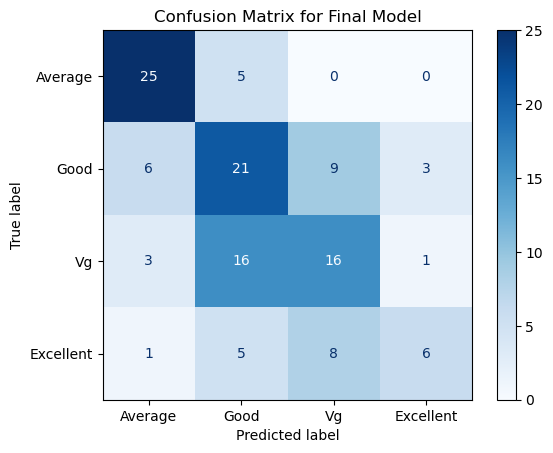

In [101]:
cm = confusion_matrix(y_test_mapped, final_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_mapping.keys())
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Final Model")
plt.show()

### Classification Report

The model handles average well. It correctly identifies 88% of average students. This is partly because the model is over-predicting Average. Excellent has the opposite problem - the model only catches 1 in 4 Excellent students. Good is the weakest class - both precision and recall are low.

In [102]:
print("Classification Report: ")
print(classification_report(y_test_mapped, final_predictions, target_names=target_mapping.keys()))

Classification Report: 
              precision    recall  f1-score   support

     Average       0.71      0.83      0.77        30
        Good       0.45      0.54      0.49        39
          Vg       0.48      0.44      0.46        36
   Excellent       0.60      0.30      0.40        20

    accuracy                           0.54       125
   macro avg       0.56      0.53      0.53       125
weighted avg       0.55      0.54      0.53       125



### Feature Importance

The strongest predictor of excellent performance is being from the General `caste` category. The next strongest predictors are private coaching, studying in a language other than English or Assamese, and having a college teacher for a parent.

In [103]:
feature_mask = final_model.named_steps['select'].get_support()
all_feature_names = final_model.named_steps['prep'].get_feature_names_out()
feature_names = all_feature_names[feature_mask]

excellent_coefs = final_model.named_steps['model'].coef_[3]

feature_importance = sorted(zip(excellent_coefs, feature_names), reverse=True)
print("\nTop features for predicting 'Excellent':")
for score, name in feature_importance[:5]:
    print(f"{name}: {score:.4f}")


Top features for predicting 'Excellent':
nom__caste_General: 0.4647
nom__coaching_OA: 0.2978
nom__mother_occupation_COLLEGE_TEACHER: 0.2001
nom__medium_OTHERS: 0.1676
nom__father_occupation_ENGINEER: 0.1547


## Save the Final Model

In [104]:
joblib.dump(final_model, 'final_model.joblib')
print("Model saved as final_model.joblib")

Model saved as final_model.joblib


# Auction Verification Regression Project

**Dataset:** Auction Verification dataset (CSV). Each instance describes an online
auction's process capacities and property attributes.  
**Task:** Predict `verification.time` — the time in seconds to verify an auction —
a continuous regression target.  
**Approach:** The target is heavily right-skewed (mean 7,337s, max 44,130s), so we
apply a log transform via `TransformedTargetRegressor`. We compare three regressors
with 10-fold cross-validation, then tune the best with `GridSearchCV`.

## Data Wrangling

### Load CSV into a DataFrame and check for duplicates

In [105]:
df_reg = pd.read_csv("../data/raw/data.csv")

# Drop the classification target - we are only predicting price
df_reg = df_reg.drop(columns=["verification.result"])

before = len(df_reg)
df_reg.drop_duplicates(inplace=True)
print(f"Removed {before - len(df_reg)} duplicate rows ({len(df_reg)} remaining)")

print(df_reg.head())

Removed 0 duplicate rows (2043 remaining)
   process.b1.capacity  process.b2.capacity  process.b3.capacity  \
0                    0                    0                    2   
1                    0                    0                    2   
2                    0                    0                    2   
3                    0                    0                    2   
4                    0                    0                    2   

   process.b4.capacity  property.price  property.product  property.winner  \
0                    1              59                 1                0   
1                    1              59                 2                0   
2                    1              59                 4                0   
3                    1              59                 6                0   
4                    1              60                 1                0   

   verification.time  
0         163.316667  
1         200.860000  
2         154.888

### Examining the Data Structure

In [106]:
print('First five rows of DataFrame: \n', df_reg.head(), '\n')
print('Shape of DataFrame: ', df_reg.shape, '\n')

First five rows of DataFrame: 
    process.b1.capacity  process.b2.capacity  process.b3.capacity  \
0                    0                    0                    2   
1                    0                    0                    2   
2                    0                    0                    2   
3                    0                    0                    2   
4                    0                    0                    2   

   process.b4.capacity  property.price  property.product  property.winner  \
0                    1              59                 1                0   
1                    1              59                 2                0   
2                    1              59                 4                0   
3                    1              59                 6                0   
4                    1              60                 1                0   

   verification.time  
0         163.316667  
1         200.860000  
2         154.888889  
3   

### Check Feature Distributions

In [107]:
print(df_reg.describe(), '\n')

       process.b1.capacity  process.b2.capacity  process.b3.capacity  \
count          2043.000000          2043.000000          2043.000000   
mean              1.000000             2.093979             1.883994   
std               0.816696             0.811269             0.320310   
min               0.000000             0.000000             1.000000   
25%               0.000000             1.000000             2.000000   
50%               1.000000             2.000000             2.000000   
75%               2.000000             3.000000             2.000000   
max               2.000000             3.000000             2.000000   

       process.b4.capacity  property.price  property.product  property.winner  \
count          2043.000000     2043.000000       2043.000000      2043.000000   
mean              0.587861       71.473324          3.252080         0.455213   
std               0.492340        8.048740          1.804225         1.062828   
min               0.000000 

The target `verification.time` is heavily right-skewed. The max (44,130s) is far above the mean (7,337s) which is far above the median (1,317s).

In [125]:
Q1 = df_reg["verification.time"].quantile(0.25)
Q3 = df_reg["verification.time"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = df_reg[df_reg["verification.time"] > upper_bound]
print(f"IQR upper fence: {upper_bound:.0f}s")
print(f"Outliers above upper fence: {len(outliers)} ({len(outliers)/len(df_reg)*100:.1f}%)")
print(outliers["verification.time"].describe())

IQR upper fence: 26371s
Outliers above upper fence: 206 (10.1%)
count      206.000000
mean     31838.706063
std       3759.592831
min      26386.000000
25%      28887.570833
50%      31208.572917
75%      34077.648438
max      44130.520833
Name: verification.time, dtype: float64


### Create the Target and Set Aside a Test Set

In [108]:
X_reg = df_reg.drop(columns=['verification.time'])
y_reg = df_reg['verification.time']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED, stratify=X_reg['property.winner'])

Below you can see that `property.winner` is massively inbalanced. For that reason we stratify our train_test_split() on `property.winner`.

### Visualize Distribution

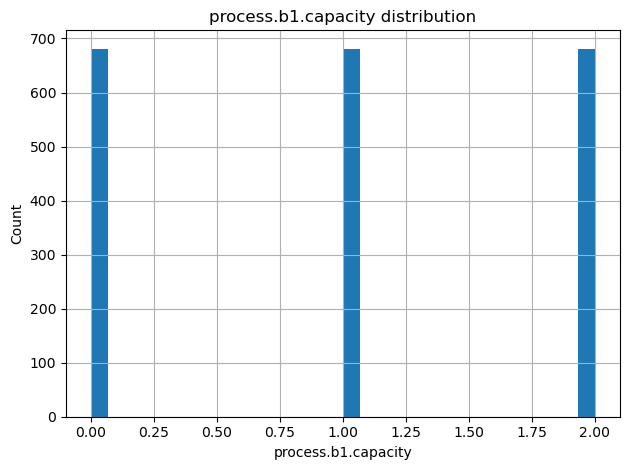

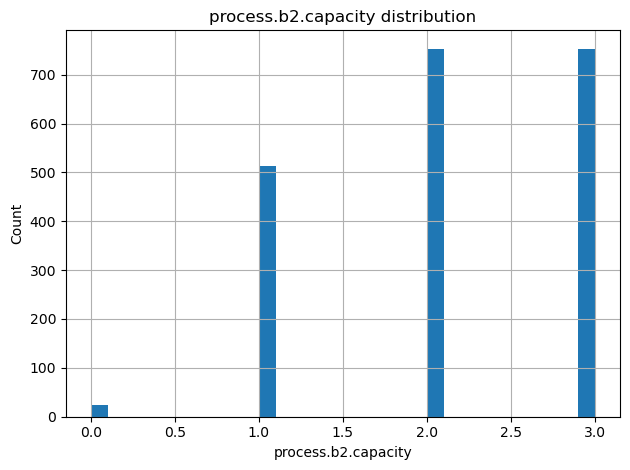

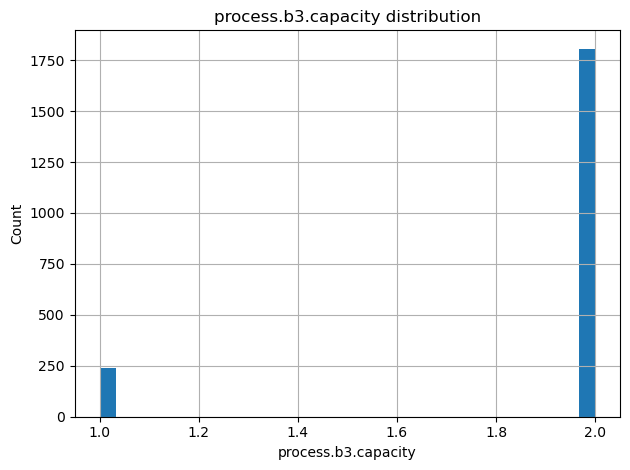

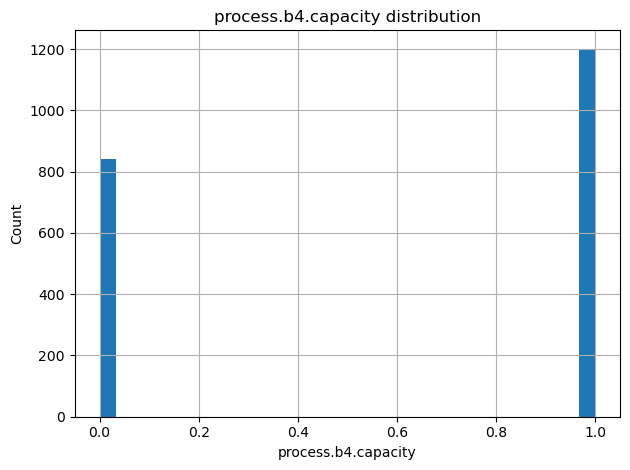

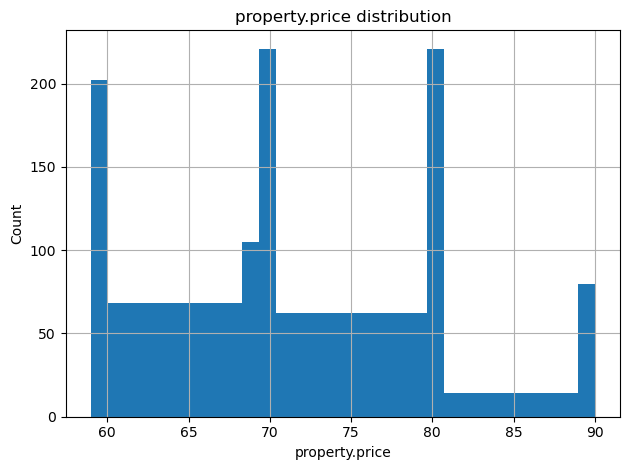

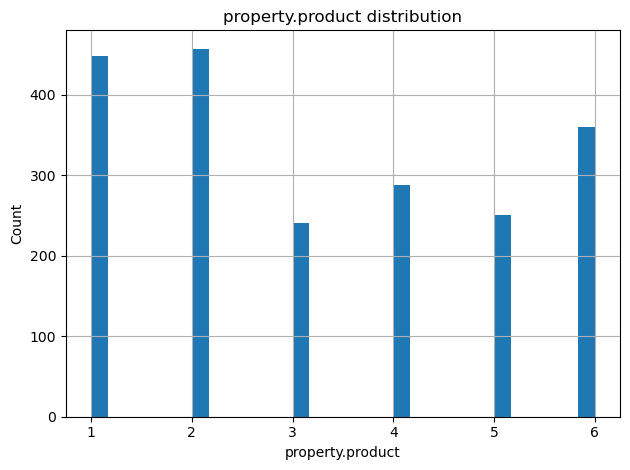

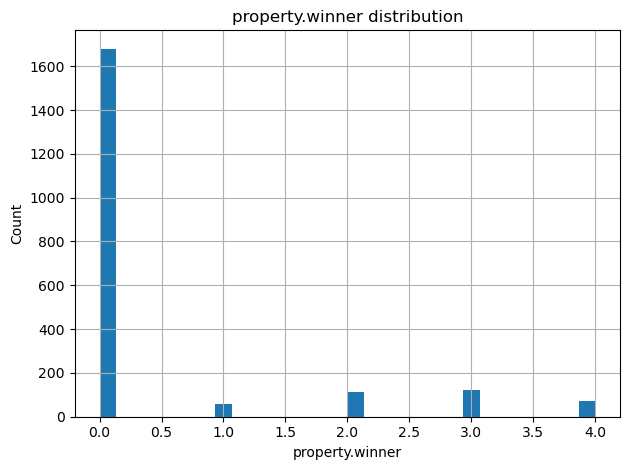

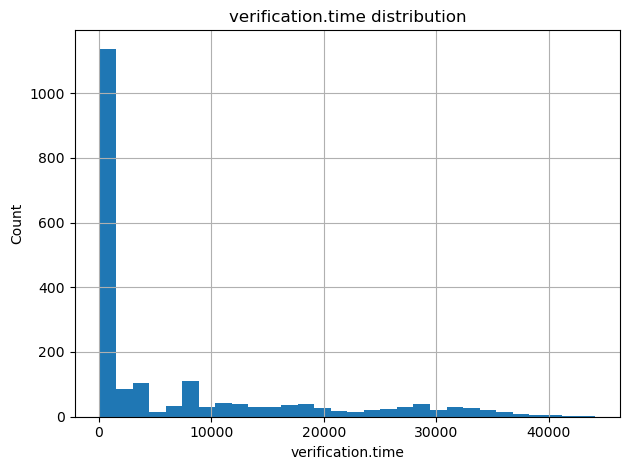

In [109]:
for col in df_reg.columns:
    plt.figure()
    df_reg[col].hist(bins=30, grid=True)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.title(f'{col} distribution')
    plt.tight_layout()
    plt.show()

### Look for Relationships and Correlations

Here we use Pearson correlation to check how strongly each feature is linearly associated with the target. We correlate against the log-transformed target, since that is what our models will effectively be fitting.

Correlation with log(verification.time): 
 process.b1.capacity    0.533449
process.b3.capacity    0.347780
property.product      -0.319759
property.winner       -0.217987
property.price         0.172691
process.b4.capacity    0.089885
process.b2.capacity    0.088945
Name: log_time, dtype: float64 



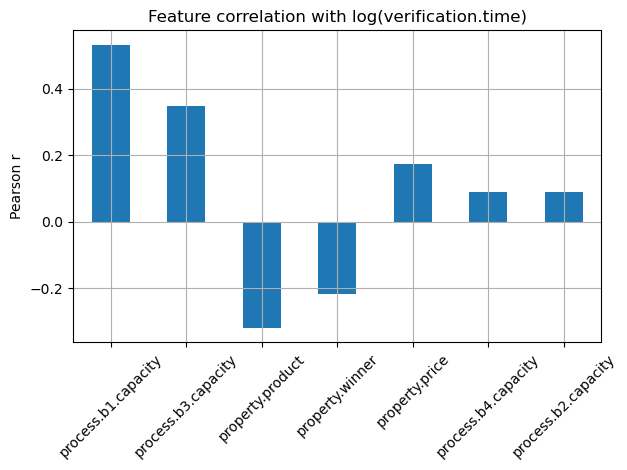

In [110]:
df_reg_corr = df_reg.copy()
df_reg_corr['log_time'] = np.log(df_reg['verification.time'])

corr = df_reg_corr.corr()['log_time'].drop(['verification.time', 'log_time']).sort_values(key=abs, ascending=False)
print('Correlation with log(verification.time): \n', corr, '\n')

corr.plot.bar(rot=45, grid=True)
plt.ylabel('Pearson r')
plt.title('Feature correlation with log(verification.time)')
plt.tight_layout()
plt.show()

### Clean Data

No columns are dropped. We save the processed file for reproducibility.

In [111]:
df_reg.to_csv("../data/processed/Auction_Verification.csv", index=False)

## Feature Transformation

### Log-Transform the Target

`verification.time` is heavily right-skewed, so we log-transform the target to compress the tail. This is required for Linear Regression's normality assumption and benefits the other models as well.

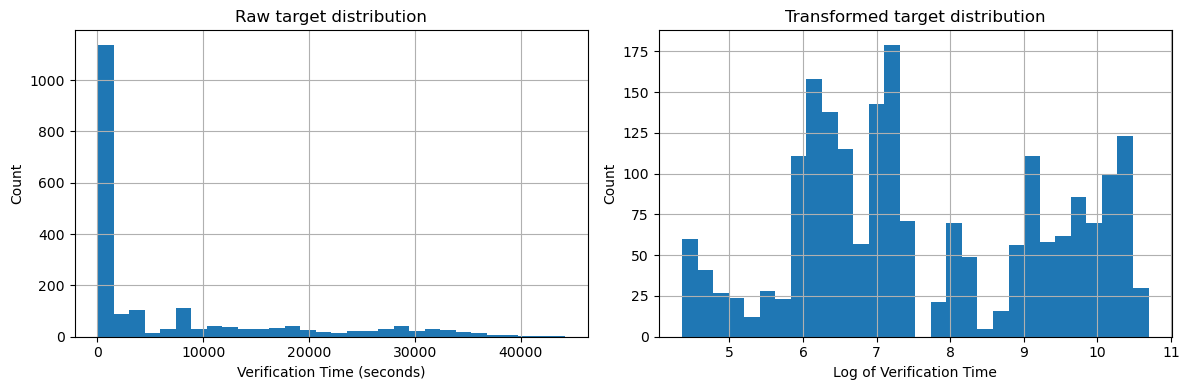

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_reg['verification.time'].hist(bins=30, grid=True, ax=axes[0])
axes[0].set_xlabel('Verification Time (seconds)')
axes[0].set_ylabel('Count')
axes[0].set_title('Raw target distribution')

np.log(df_reg['verification.time']).hist(bins=30, grid=True, ax=axes[1])
axes[1].set_xlabel('Log of Verification Time')
axes[1].set_ylabel('Count')
axes[1].set_title('Transformed target distribution')

plt.tight_layout()
plt.show()

### Define the Preprocessing Pipeline

In [113]:
reg_preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), list(X_reg.columns))
    ]
)

## Baseline Models

### Build Baseline Model Pipelines

We wrap each model in a `TransformedTargetRegressor` with a log transform on the target. The model will train on log(`verification.time`) internally, and predictions are converted back to seconds before being returned.

In [114]:
log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)

knn_reg_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        KNeighborsRegressor(n_neighbors=5),
        transformer=log_transformer
    ))
])

lr_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        LinearRegression(),
        transformer=log_transformer
    ))
])

svr_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('select', SelectKBest(score_func=f_regression, k=5)),
    ('model', TransformedTargetRegressor(
        SVR(kernel='rbf'),
        transformer=log_transformer
    ))
])

rf_pipe = Pipeline([
    ('prep', reg_preprocessor),
    ('model', TransformedTargetRegressor(
        RandomForestRegressor(n_estimators=100, random_state=SEED),
        transformer=log_transformer
    ))
])

### Initial Evaluation via Cross-Validation

In [115]:
reg_models = [('kNN', knn_reg_pipe), ('Linear Regression', lr_pipe), ('SVR', svr_pipe), ('Random Forest', rf_pipe)]

for name, pipeline in reg_models:
    results = cross_validate(
        pipeline, X_reg_train, y_reg_train,
        cv=10,
        scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'],
        return_train_score=True
    )

    train_rmse = np.sqrt(-results['train_neg_mean_squared_error']).mean()
    val_rmse = np.sqrt(-results['test_neg_mean_squared_error']).mean()
    mean_r2 = results['test_r2'].mean()
    mean_mae = -results['test_neg_mean_absolute_error'].mean()

    print(f"{name}: Train RMSE: {train_rmse: .2f}s | Val RMSE: {val_rmse: .2f}s | R^2: {mean_r2: .4f} | MAE: {mean_mae: .2f}s")
    if train_rmse < val_rmse * 0.8:
        print(f" Warning: {name} may be overfitting.")

kNN: Train RMSE:  2900.27s | Val RMSE:  3796.40s | R^2:  0.8533 | MAE:  1750.35s
Linear Regression: Train RMSE:  9290.47s | Val RMSE:  9272.07s | R^2:  0.1460 | MAE:  5109.11s
SVR: Train RMSE:  7051.89s | Val RMSE:  7141.95s | R^2:  0.4927 | MAE:  3675.63s
Random Forest: Train RMSE:  344.25s | Val RMSE:  902.95s | R^2:  0.9915 | MAE:  408.02s


Baseline ranking by R²: Random Forest (0.9915), kNN (0.8533), SVR (0.4927), Linear Regression.
SVR and kNN both have significant room for improvement through tuning. Linear Regression's weak
baseline reflects a non-linear target relationship; we carry it forward without tuning.

## Hyperparameter Tuning

In [116]:
knn_reg_param_grid = {
    'select__k': [3, 4, 5],
    'model__regressor__n_neighbors': [3, 5, 7, 9],
    'model__regressor__weights': ['uniform', 'distance'],
    'model__regressor__metric': ['euclidean', 'manhattan']
}
knn_reg_grid = GridSearchCV(knn_reg_pipe, knn_reg_param_grid, cv=10, scoring='r2', verbose=1)
knn_reg_grid.fit(X_reg_train, y_reg_train)
print(f"KNN Regressor best params: {knn_reg_grid.best_params_}")
print(f"KNN Regressor best CV R²: {knn_reg_grid.best_score_:.4f}")

Fitting 10 folds for each of 48 candidates, totalling 480 fits
KNN Regressor best params: {'model__regressor__metric': 'manhattan', 'model__regressor__n_neighbors': 7, 'model__regressor__weights': 'distance', 'select__k': 5}
KNN Regressor best CV R²: 0.9521


In [117]:
svr_param_grid = {
    'select__k': [3, 5],
    'model__regressor__C': [0.1, 1, 10, 100],
    'model__regressor__epsilon': [0.01, 0.1, 1],
    'model__regressor__kernel': ['rbf', 'linear']
}
svr_grid = GridSearchCV(svr_pipe, svr_param_grid, cv=5, scoring='r2', verbose=1)  # cv=5 not 10 — SVR is slow
svr_grid.fit(X_reg_train, y_reg_train)
print(f"SVR best params: {svr_grid.best_params_}")
print(f"SVR best CV R²: {svr_grid.best_score_:.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
SVR best params: {'model__regressor__C': 10, 'model__regressor__epsilon': 0.1, 'model__regressor__kernel': 'rbf', 'select__k': 3}
SVR best CV R²: 0.8661


In [118]:
rf_param_grid = [
    {
        'model__regressor__n_estimators': [100, 200, 500],
        'model__regressor__max_depth': [5, 10, 20, None],
        'model__regressor__min_samples_leaf': [1, 5, 10],
    }
]

reg_grid_search = GridSearchCV(rf_pipe, rf_param_grid, cv=10, scoring='r2', return_train_score=True, verbose=1)

reg_grid_search.fit(X_reg_train, y_reg_train)

results_df = pd.DataFrame(reg_grid_search.cv_results_)
results_df['gap'] = results_df['mean_train_score'] - results_df['mean_test_score']
print(results_df[['params', 'mean_train_score', 'mean_test_score', 'gap']].sort_values('mean_test_score', ascending=False).head(10))

Fitting 10 folds for each of 36 candidates, totalling 360 fits
                                               params  mean_train_score  \
29  {'model__regressor__max_depth': None, 'model__...          0.998900   
20  {'model__regressor__max_depth': 20, 'model__re...          0.998900   
28  {'model__regressor__max_depth': None, 'model__...          0.998857   
19  {'model__regressor__max_depth': 20, 'model__re...          0.998857   
27  {'model__regressor__max_depth': None, 'model__...          0.998829   
18  {'model__regressor__max_depth': 20, 'model__re...          0.998829   
11  {'model__regressor__max_depth': 10, 'model__re...          0.995729   
10  {'model__regressor__max_depth': 10, 'model__re...          0.995676   
9   {'model__regressor__max_depth': 10, 'model__re...          0.995606   
23  {'model__regressor__max_depth': 20, 'model__re...          0.984173   

    mean_test_score       gap  
29         0.991681  0.007219  
20         0.991681  0.007219  
28         0.99

## Final Evaluation

### Results

In [119]:
reg_final_model = reg_grid_search.best_estimator_

y_reg_pred = reg_final_model.predict(X_reg_test)

final_r2 = r2_score(y_reg_test, y_reg_pred)
final_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
final_mae = mean_absolute_error(y_reg_test, y_reg_pred)

print(f"Final test R^2: {final_r2: .4f}")
print(f"Final test RMSE: {final_rmse: .4f}")
print(f"Final test MAE: {final_mae: .4f}")

Final test R^2:  0.9911
Final test RMSE:  1078.4898
Final test MAE:  523.9063


### Residuals Plot

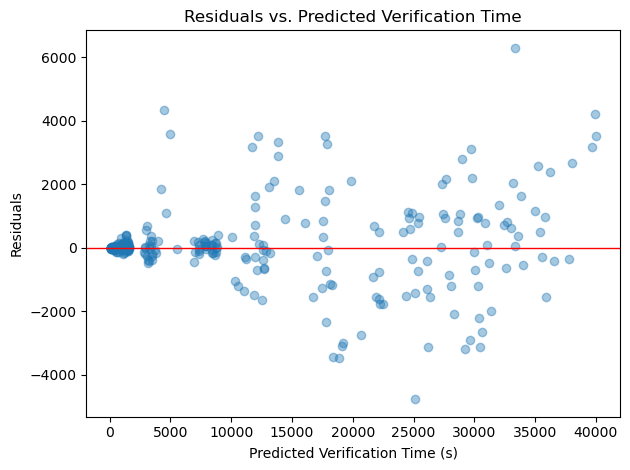

In [120]:
residuals = y_reg_test - y_reg_pred

plt.scatter(y_reg_pred, residuals, alpha=0.4)
plt.axhline(0, color='red', linewidth=1)
plt.xlabel('Predicted Verification Time (s)')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Verification Time')
plt.tight_layout()
plt.show()

### Predicted vs. Actual Plot

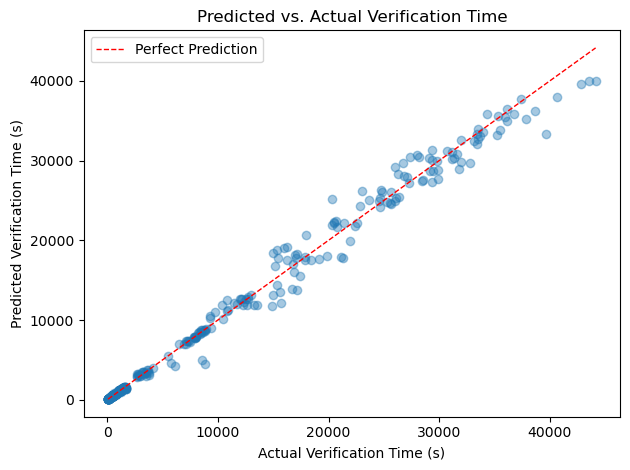

In [121]:
plt.scatter(y_reg_test, y_reg_pred, alpha=0.4)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--', linewidth=1, label='Perfect Prediction')
plt.xlabel('Actual Verification Time (s)')
plt.ylabel('Predicted Verification Time (s)')
plt.title('Predicted vs. Actual Verification Time')
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance

Feature importances (Random Forest):
property.product: 0.4173
process.b1.capacity: 0.3920
property.winner: 0.0734
property.price: 0.0599
process.b4.capacity: 0.0494
process.b2.capacity: 0.0078
process.b3.capacity: 0.0001


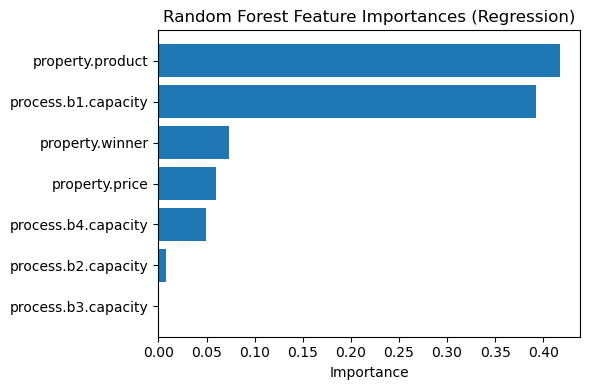

In [122]:
all_feature_names = list(X_reg.columns)

importances = reg_final_model.named_steps['model'].regressor_.feature_importances_

feature_importance = sorted(zip(importances, all_feature_names), key=lambda x: x[0], reverse=True)
print("Feature importances (Random Forest):")
for imp, name in feature_importance:
    print(f"{name}: {imp:.4f}")

feature_names = list(X_reg.columns)

sorted_idx = np.argsort(importances)
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances (Regression)')
plt.tight_layout()
plt.savefig('feature_importance_reg.png', dpi=150)
plt.show()

## Save the Final Model

In [123]:
joblib.dump(reg_final_model, 'final_regression_model.joblib')
print('Model saved as final_regression_model.joblib')

Model saved as final_regression_model.joblib


### Classification — CEE Student Performance
*(Baseline: 25% random chance, 4 classes)*

| Model | Owner | Baseline CV Acc | Tuned CV Acc | CV Macro F1 | Test Accuracy | Test Macro F1 |
|-------|-------|-----------------|--------------|-------------|---------------|---------------|
| kNN | Zach | 0.4284 | 0.4850 | 0.3906 | — | — |
| **Logistic Regression** ✓ | Alan | **0.5171** | **0.5211** | **0.4896** | **0.5440** | **0.53** |
| Gaussian NB | Miguel | 0.4305 | 0.5091 | 0.3519 | — | — |

### Regression — Auction Verification
*(Target mean: 7,337 s; log-transformed target throughout)*

| Model | Owner | Baseline CV R² | Tuned CV R² | Test R² | Test RMSE |
|-------|-------|----------------|-------------|---------|-----------|
| kNN | Zach | 0.8533 | 0.9521 | — | — |
| SVR | Miguel | 0.4927 | 0.8661 | — | — |
| **Random Forest** ✓ | Alan | **0.9915** | **0.9917** | **0.9911** | **1,078 s** |
| Linear Regression | — | ~0.49 | — | — | — |

`✓` Selected for final evaluation